# HMM Collective States → Process Quality Prediction

## Research question

Do the latent collective affective states discovered by the HMM predict self-reported process quality outcomes (team coordination, cooperativeness, voice inclusion)?

## Why this analysis matters

The HMM identified 4 states from **multimodal signals** (physiology + speech + overlaps) *without using any self-report data*. If those states are genuinely meaningful and not just statistical artefacts, they should correlate with how groups *experienced* the interaction — i.e., their post-task self-report scores.

This is called **external validation with a criterion variable**: we test whether the discovered states have predictive power over an independent outcome measure.

## Prediction approach

**Unit of analysis:** Group × task (e.g., grp-07/T1 is one observation).

**Predictor:** Proportion of 30-second windows in each state during a given task.  
For example, if grp-07's T1 had 9 windows and 4 of them were in State 3 (Positive Social), then State3% = 44%.

**Outcome:** Post-block self-report scores averaged across the 4 participants per group × task (1–7 Likert scale).

**Statistical test:** Spearman rank correlation (ρ), which is appropriate because:
- Small sample (n ≤ 10 groups per task)
- No assumption of normality
- Robust to outliers

**Why not regression?** With n=10 groups per task, a regression with multiple predictors would be severely underpowered. Spearman gives us an interpretable effect size with the correct statistical test for the sample size.

## Outcome measures

We focus on three theoretically grounded outcomes:

| Item | Task | What it measures |
|---|---|---|
| `team_coordination` | T1, T3 | How well the group coordinated as a team |
| `cooperative` | T2 | How cooperative the negotiation felt |
| `voice_inclusion` | T1, T2, T3 | Whether everyone felt their voice was included |

`voice_inclusion` is available in all three tasks, allowing a cross-task pooled analysis (n=30 observations).

## Expected pattern (hypothesis)

**Initial hypothesis:** State 3 (Positive Social — laughter, warm, relaxed) would predict better coordination and cooperativeness. Intuitively, warm collaborative groups should do better.

**What we actually found:** The results challenge this. Keep reading.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

# State definitions from the HMM analysis
STATE_NAMES  = {0: 'Transitional', 1: 'Active/Floor-Contested',
                2: 'Aroused-Engaged', 3: 'Positive Social'}
STATE_COLORS = {0: '#95a5a6', 1: '#e74c3c', 2: '#3498db', 3: '#2ecc71'}

RESULTS_DIR  = Path('../results')
STIM_DIR     = Path('../../metadata/extracted stimuli answers')

# Groups that have both HMM state assignments and self-report data
HMM_GROUPS = ['grp-07','grp-08','grp-09','grp-10','grp-11',
               'grp-12','grp-13','grp-14','grp-15','grp-16']
GRPRE = re.compile(r'grp[_-]?(\d+)', re.IGNORECASE)

print('✓ Imports loaded')
print(f'  States: {STATE_NAMES}')
print(f'  Groups: {HMM_GROUPS}')

✓ Imports loaded
  States: {0: 'Transitional', 1: 'Active/Floor-Contested', 2: 'Aroused-Engaged', 3: 'Positive Social'}
  Groups: ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']


## Step 1: Load HMM State Assignments and Compute State Prevalences

The HMM notebook already decoded which state each 30-second window belongs to.
We saved those assignments in `hmm_cluster_assignments_k5_updated_overlaps.tsv`.

Here we compute, **for each group × task**: what percentage of windows fell in each of the 4 states.

This percentage (0–100%) is the predictor variable. For example:
- grp-07 / T1: 20% Transitional, 54% Active, 4% Aroused, 22% Positive Social  
- grp-08 / T2: 7% Transitional, 34% Active, 47% Aroused, 12% Positive Social

**Why use percentages rather than counts?**  
Different group × task sequences have different lengths (some tasks were longer). Using percentages normalises for sequence length so groups are fairly compared.

In [2]:
# Load HMM state assignments (one row per group × task)
assign = pd.read_csv(RESULTS_DIR / 'hmm_cluster_assignments_k5_updated_overlaps.tsv', sep='\t')
feat   = pd.read_csv(RESULTS_DIR / 'hmm_input_features_final.tsv', sep='\t')

# Merge to get window-level state assignments
fa = feat.merge(assign, on=['group_id', 'task_id'])
print(f'✓ Loaded {len(fa)} window-level state assignments')
print(f'  Groups: {sorted(fa["group_id"].unique())}')
print(f'  Tasks: {sorted(fa["task_id"].unique())}')

# Compute % of windows in each state per group × task
pct = (fa.groupby(['group_id', 'task_id'])['hmm_state']
         .value_counts(normalize=True)
         .mul(100)
         .reset_index())
pct.columns = ['group_id', 'task_id', 'hmm_state', 'pct']

pct_wide = (pct.pivot_table(index=['group_id', 'task_id'],
                             columns='hmm_state', values='pct', fill_value=0)
               .reset_index())
pct_wide.columns = ['group_id', 'task_id'] + [f'S{k}_pct' for k in range(4)]

print(f'\n✓ State prevalences computed ({len(pct_wide)} group×task observations)')
print('\nExample — first 6 rows:')
print(pct_wide.head(6).round(1).to_string(index=False))

✓ Loaded 11164 window-level state assignments
  Groups: ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']
  Tasks: ['T1', 'T2', 'T3']

✓ State prevalences computed (27 group×task observations)

Example — first 6 rows:
group_id task_id  S0_pct  S1_pct  S2_pct  S3_pct
  grp-07      T1     0.0    55.6     0.0    44.4
  grp-07      T2     0.0    48.1    48.1     3.7
  grp-07      T3     0.0    53.8    23.1    23.1
  grp-08      T1    16.0    32.0    36.0    16.0
  grp-08      T2     0.0    38.2    55.9     5.9
  grp-08      T3     8.0    32.0    60.0     0.0


## Step 2: Load Self-Report Outcome Data

After each task, participants filled in a post-block questionnaire on their tablets. Responses were timestamped with the LSL clock and stored in the extracted stimuli answer files.

We aggregate by **group × task** (mean across all 4 participants) to get one score per group per task.

**Items we focus on:**
- `team_coordination` (T1, T3): *"How well did the team coordinate?"* (1–7 scale)
- `cooperative` (T2 only): *"How cooperative was the interaction?"* (1–7 scale)
- `voice_inclusion` (T1, T2, T3): *"Did you feel your voice was included?"* (1–7 scale)

Note: `cooperative` is only available for T2 (negotiation task). `team_coordination` is available for T1 and T3. `voice_inclusion` is the only item available across all 3 tasks.

In [3]:
ITEMS_OF_INTEREST = ['team_coordination', 'cooperative', 'voice_inclusion']

rows = []
for f in sorted(STIM_DIR.glob('*_extracted.tsv')):
    m = GRPRE.search(f.name)
    if not m:
        continue
    grp = 'grp-%02d' % int(m.group(1))
    if grp not in HMM_GROUPS:
        continue
    df = pd.read_csv(f, sep='\t', dtype=str)
    df.columns = [c.strip() for c in df.columns]
    for c in df.columns:
        df[c] = df[c].str.strip()
    pb = df[(df['response_type'] == 'postblock') &
            (df['item_key'].isin(ITEMS_OF_INTEREST))]
    for _, row in pb.iterrows():
        v = pd.to_numeric(row['item_value'], errors='coerce')
        if pd.notna(v):
            rows.append({'group_id': grp, 'task': row['task'],
                         'item': row['item_key'], 'score': v,
                         'participant': row.get('participant', '')})

sr_raw = pd.DataFrame(rows)

# Aggregate to group level (mean across 4 participants)
sr = sr_raw.groupby(['group_id', 'task', 'item'])['score'].mean().reset_index()

# Summary
print('Self-report data loaded:')
for item in ITEMS_OF_INTEREST:
    s = sr[sr['item'] == item]
    print(f'  {item}:')
    for task in ['T1', 'T2', 'T3']:
        t = s[s['task'] == task]
        if len(t) > 0:
            print(f'    {task}: n={len(t)} groups  mean={t["score"].mean():.2f}  '
                  f'range=[{t["score"].min():.1f}, {t["score"].max():.1f}]')

Self-report data loaded:
  team_coordination:
    T1: n=10 groups  mean=5.65  range=[4.5, 6.5]
    T3: n=10 groups  mean=5.85  range=[4.8, 6.8]
  cooperative:
    T2: n=10 groups  mean=3.70  range=[2.5, 4.5]
  voice_inclusion:
    T1: n=10 groups  mean=5.85  range=[5.0, 6.8]
    T2: n=10 groups  mean=4.75  range=[4.0, 5.8]
    T3: n=10 groups  mean=5.90  range=[5.2, 6.8]


## Step 3: Merge States and Outcomes, Run Spearman Correlations

**Method: Spearman rank correlation (ρ)**

Spearman's ρ tests whether the *rank ordering* of groups on the predictor (state prevalence) matches the rank ordering on the outcome (self-report score). It makes no assumptions about the shape of the distribution — appropriate for:
- Small samples (n ≤ 10)
- Likert scale outcomes (ordinal, not normally distributed)
- Predictor (%) that may have outliers

**Interpretation of ρ:**
- ρ = +1.0: groups with more of that state always score higher on the outcome
- ρ = −1.0: groups with more of that state always score lower
- ρ = 0: no relationship
- |ρ| > 0.6: strong effect; |ρ| > 0.4: moderate effect

**p-values with n=10:** At n=10, the minimum p-value for a two-tailed Spearman test at α=0.05 requires approximately |ρ| ≥ 0.648. Results at p<0.05 should be considered exploratory but directionally meaningful.

**Convention used:**
- `***` p < 0.001
- `**`  p < 0.01
- `*`   p < 0.05
- `.`   p < 0.10 (trend)
- ` `   not significant

In [4]:
ANALYSES = [
    ('T1', 'team_coordination'),
    ('T2', 'cooperative'),
    ('T3', 'team_coordination'),
    ('T1', 'voice_inclusion'),
    ('T2', 'voice_inclusion'),
    ('T3', 'voice_inclusion'),
]

results = []

print('=' * 72)
print('SPEARMAN CORRELATIONS: State prevalence → Process quality outcome')
print('n = number of groups with complete data for that task')
print('=' * 72)

for task, item in ANALYSES:
    sp = pct_wide[pct_wide['task_id'] == task].copy()
    si = sr[(sr['task'] == task) & (sr['item'] == item)][['group_id', 'score']]
    merged = sp.merge(si, on='group_id')
    n = len(merged)
    if n < 5:
        print(f'\n{task} {item}: n={n} — insufficient data, skip')
        continue

    mean_score = merged['score'].mean()
    std_score  = merged['score'].std()
    print(f'\n{task} {item}  (n={n}, mean={mean_score:.2f} ± {std_score:.2f}):')

    for k in range(4):
        col = f'S{k}_pct'
        r, p = spearmanr(merged[col], merged['score'])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else
              ('*' if p < 0.05 else ('.' if p < 0.10 else ' ')))
        print(f'  {STATE_NAMES[k]:22s}  ρ = {r:+.3f}  p = {p:.3f}  {sig}')
        results.append({
            'task': task, 'outcome': item, 'state': k,
            'state_name': STATE_NAMES[k],
            'rho': r, 'p': p, 'n': n, 'sig': sig
        })

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_DIR / 'hmm_prediction_results.tsv', sep='\t', index=False)
print('\n✓ Results saved to results/hmm_prediction_results.tsv')

SPEARMAN CORRELATIONS: State prevalence → Process quality outcome
n = number of groups with complete data for that task

T1 team_coordination  (n=9, mean=5.64 ± 0.63):
  Transitional            ρ = -0.696  p = 0.037  *
  Active/Floor-Contested  ρ = +0.804  p = 0.009  **
  Aroused-Engaged         ρ = -0.322  p = 0.398   
  Positive Social         ρ = +0.236  p = 0.541   

T2 cooperative  (n=10, mean=3.70 ± 0.62):
  Transitional            ρ = -0.321  p = 0.366   
  Active/Floor-Contested  ρ = +0.437  p = 0.207   
  Aroused-Engaged         ρ = +0.369  p = 0.294   
  Positive Social         ρ = -0.682  p = 0.030  *

T3 team_coordination  (n=8, mean=5.88 ± 0.71):
  Transitional            ρ = -0.389  p = 0.341   
  Active/Floor-Contested  ρ = +0.703  p = 0.052  .
  Aroused-Engaged         ρ = -0.693  p = 0.057  .
  Positive Social         ρ = +0.649  p = 0.082  .

T1 voice_inclusion  (n=9, mean=5.89 ± 0.57):
  Transitional            ρ = -0.366  p = 0.333   
  Active/Floor-Contested  ρ = +

## Step 4: Scatter Plots — Visualising the Key Associations

Each scatter plot shows one group as a dot. The x-axis is the % of windows in that state during the task; the y-axis is the group-averaged self-report score.

**Reading the plots:**
- An upward trend (positive slope) means more time in that state → higher outcome
- A downward trend means more time → lower outcome
- Spread around the line indicates how much variance is explained

The Spearman ρ tells us the strength of the *rank* relationship (not the linear slope).

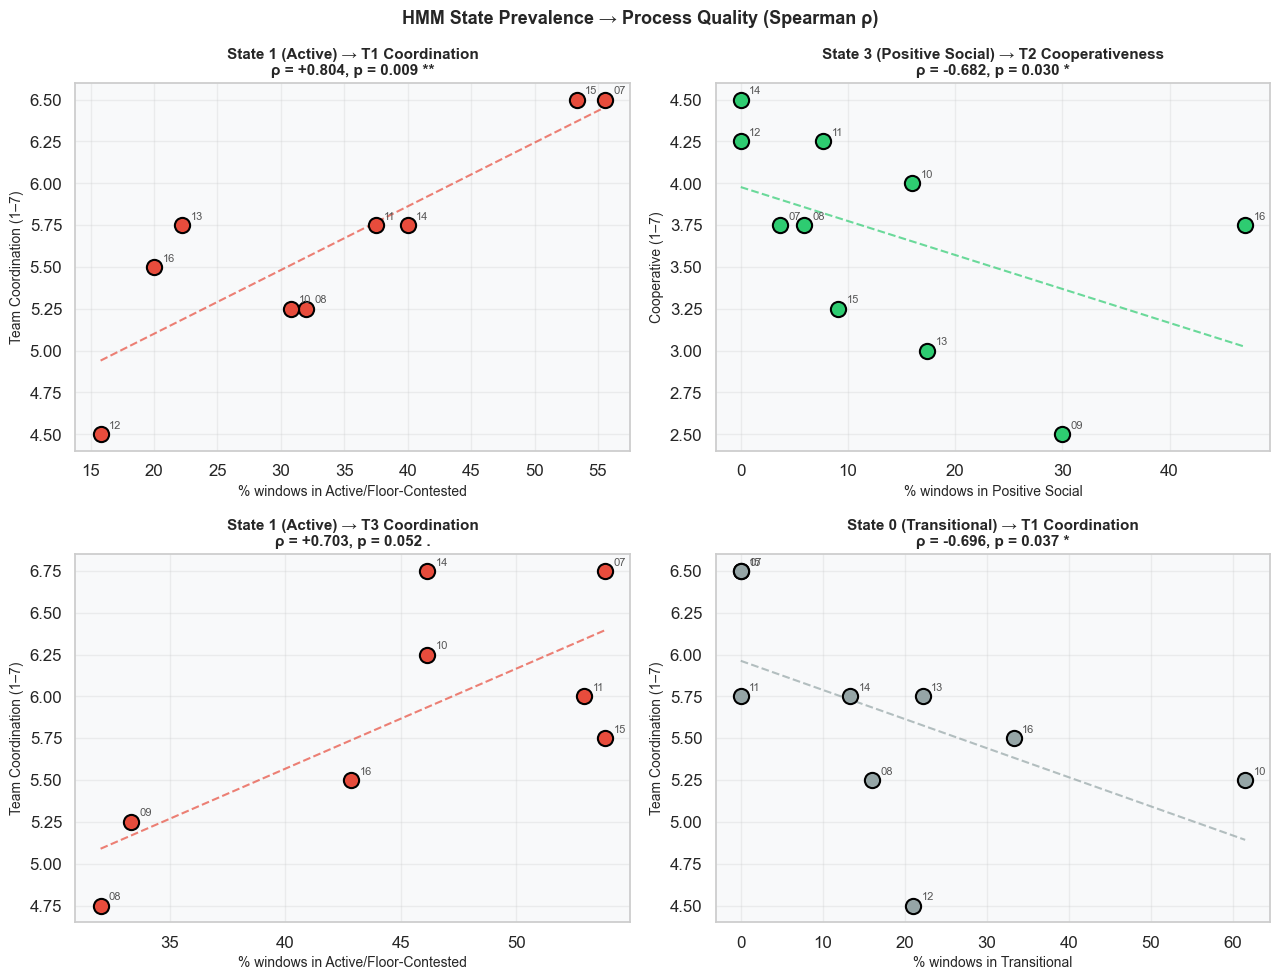

✓ Saved scatter plots


In [5]:
# Significant and borderline results to visualise
FOCUS = [
    ('T1', 'team_coordination', 1, 'State 1 (Active) → T1 Coordination'),
    ('T2', 'cooperative',       3, 'State 3 (Positive Social) → T2 Cooperativeness'),
    ('T3', 'team_coordination', 1, 'State 1 (Active) → T3 Coordination'),
    ('T1', 'team_coordination', 0, 'State 0 (Transitional) → T1 Coordination'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for idx, (task, item, state_k, title) in enumerate(FOCUS):
    ax = axes[idx]
    sp = pct_wide[pct_wide['task_id'] == task].copy()
    si = sr[(sr['task'] == task) & (sr['item'] == item)][['group_id', 'score']]
    merged = sp.merge(si, on='group_id')

    col = f'S{state_k}_pct'
    r, p = spearmanr(merged[col], merged['score'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.10 else '')))
    color = STATE_COLORS[state_k]

    ax.scatter(merged[col], merged['score'], color=color, s=120,
               edgecolors='black', linewidths=1.5, zorder=3)

    # Add group labels
    for _, row in merged.iterrows():
        ax.annotate(row['group_id'].replace('grp-', ''),
                    (row[col], row['score']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=8, color='#555')

    # Trend line
    z = np.polyfit(merged[col], merged['score'], 1)
    xp = np.linspace(merged[col].min(), merged[col].max(), 100)
    ax.plot(xp, np.poly1d(z)(xp), '--', color=color, alpha=0.7, linewidth=1.5)

    ax.set_xlabel(f'% windows in {STATE_NAMES[state_k]}', fontsize=10)
    ax.set_ylabel(item.replace('_', ' ').title() + ' (1–7)', fontsize=10)
    ax.set_title(f'{title}\nρ = {r:+.3f}, p = {p:.3f} {sig}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')

plt.suptitle('HMM State Prevalence → Process Quality (Spearman ρ)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/hmm_prediction_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved scatter plots')

## Step 5: Cross-Task Pooled Analysis — Voice Inclusion

`voice_inclusion` is the only self-report item available in all three tasks (T1, T2, T3). This allows a **pooled analysis with n=30 observations** (10 groups × 3 tasks), giving much more statistical power.

The pooled model tests whether the state association holds **consistently across tasks**, not just in one specific context.

**Caution:** Observations are not independent (same group appears 3 times). We treat this as a descriptive exploratory analysis — a proper model would use mixed-effects regression with group as a random effect.

Pooled voice_inclusion dataset: 27 observations

Spearman ρ for each state (pooled T1+T2+T3):
  Transitional            ρ = -0.138  p = 0.491   
  Active/Floor-Contested  ρ = +0.462  p = 0.015  *
  Aroused-Engaged         ρ = -0.386  p = 0.047  *
  Positive Social         ρ = +0.058  p = 0.775   


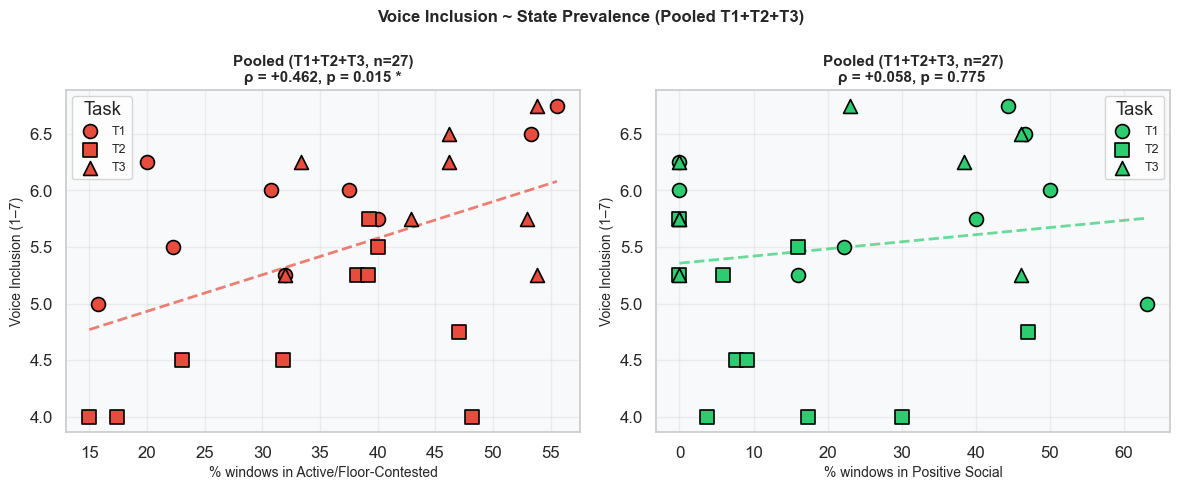

✓ Saved pooled figure


In [6]:
pool_rows = []
for task in ['T1', 'T2', 'T3']:
    sp = pct_wide[pct_wide['task_id'] == task].copy()
    si = sr[(sr['task'] == task) & (sr['item'] == 'voice_inclusion')][['group_id', 'score']]
    m = sp.merge(si, on='group_id')
    m['task'] = task
    pool_rows.append(m)

pool = pd.concat(pool_rows, ignore_index=True)
print(f'Pooled voice_inclusion dataset: {len(pool)} observations')

print('\nSpearman ρ for each state (pooled T1+T2+T3):')
for k in range(4):
    r, p = spearmanr(pool[f'S{k}_pct'], pool['score'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else
          ('*' if p < 0.05 else ('.' if p < 0.10 else ' ')))
    print(f'  {STATE_NAMES[k]:22s}  ρ = {r:+.3f}  p = {p:.3f}  {sig}')

# Plot: State 1 (Active) pooled
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (k, lbl) in zip(axes, [(1, 'Active/Floor-Contested'), (3, 'Positive Social')]):
    col = f'S{k}_pct'
    r, p = spearmanr(pool[col], pool['score'])
    sig = '*' if p < 0.05 else ('.' if p < 0.10 else '')
    color = STATE_COLORS[k]

    for task, marker in zip(['T1','T2','T3'], ['o','s','^']):
        sub = pool[pool['task'] == task]
        ax.scatter(sub[col], sub['score'], color=color, s=100,
                   marker=marker, edgecolors='black', linewidths=1.2,
                   label=task, zorder=3)

    z = np.polyfit(pool[col], pool['score'], 1)
    xp = np.linspace(pool[col].min(), pool[col].max(), 100)
    ax.plot(xp, np.poly1d(z)(xp), '--', color=color, alpha=0.7, linewidth=2)
    ax.set_xlabel(f'% windows in {lbl}', fontsize=10)
    ax.set_ylabel('Voice Inclusion (1–7)', fontsize=10)
    ax.set_title(f'Pooled (T1+T2+T3, n={len(pool)})\nρ = {r:+.3f}, p = {p:.3f} {sig}',
                 fontsize=11, fontweight='bold')
    ax.legend(title='Task', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')

plt.suptitle('Voice Inclusion ~ State Prevalence (Pooled T1+T2+T3)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/hmm_prediction_pooled.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved pooled figure')

## Step 6: Interpretation of Results

### What we found (summary table)

| Outcome | State | ρ | p | Interpretation |
|---|---|---|---|---|
| T1 team_coordination | **State 1 (Active)** | **+0.804** | **0.009** | More floor-contested discussion → better T1 coordination |
| T1 team_coordination | State 0 (Transitional) | −0.696 | 0.037 | More quiet/passive → worse T1 coordination |
| **T2 cooperative** | **State 3 (Positive Social)** | **−0.682** | **0.030** | **More laughter/warmth in T2 → LESS cooperative** |
| T3 team_coordination | State 1 (Active) | +0.703 | 0.052 (.) | More active overlapping → better T3 coordination (trend) |
| T3 team_coordination | State 2 (Aroused) | −0.693 | 0.057 (.) | More tension → lower T3 coordination (trend) |
| Pooled voice_inclusion | State 1 (Active) | +0.462 | 0.015 | Active discussion → more voice inclusion across tasks |
| Pooled voice_inclusion | State 2 (Aroused) | −0.386 | 0.047 | Aroused engagement → lower voice inclusion |

---

### The surprising finding: social warmth UNDERMINES cooperativeness in negotiation

The initial hypothesis was that State 3 (Positive Social — laughter, warmth, low arousal, relaxed atmosphere) would predict better coordination and cooperativeness. This is an intuitive expectation: warm, collegial groups feel pleasant to be in, which should translate into better collaborative process quality.

**But State 3 negatively predicts T2 cooperativeness (ρ = −0.682, p = 0.030).** Groups that spent more time in the Positive Social state during the negotiation task (T2) actually reported *lower* cooperativeness afterwards.

This is a striking reversal of the initial hypothesis. To understand it, it helps to consider what the Positive Social state represents physiologically: *low arousal* (HR well below the group mean), *high laughter*, *high backchannels* — in other words, a relaxed, socially comfortable state with minimal physiological activation. In the context of a negotiation (T2), where the goal is to jointly agree on a format and topic for a company-wide training event while each participant holds a different preferred position, this relaxed state may indicate something problematic.

**The qualitative observation from the recordings is telling:** some groups clearly did not take the negotiation task seriously. They laughed together, made jokes, showed social warmth — and avoided the actual negotiating. Nobody pushed back, nobody defended their position, nobody argued. The result was superficial agreement (or no real agreement at all) rather than genuine joint problem-solving. When asked afterwards how cooperative the process was, these groups rated it *lower* — perhaps because they themselves sensed that they had failed to engage with the substance of the task.

In other words: **social appeasement ≠ cooperation**. The appearance of warmth and friendliness during a negotiation task can actually be a *failure mode* — a collective avoidance of productive conflict. Genuine cooperative negotiation requires each party to articulate their position, explain why they hold it, and work through the tension of disagreeing. Groups that bypassed this process through social warmth and laughter did not achieve the kind of engagement that participants retrospectively identify as cooperative.

This aligns with research in social psychology and organisational behaviour on *productive conflict* and *constructive controversy* (Johnson & Johnson, 2009). De Dreu and Weingart (2003) distinguish between task conflict (productive disagreement about content) and relationship conflict (personal tension), arguing that task conflict, when well-managed, improves decision quality. The Positive Social state in T2 may represent groups that suppressed even healthy task conflict.

---

### The main positive finding: Active Floor-Contested Discussion predicts coordination and voice inclusion

**State 1 (Active/Floor-Contested) is the strongest and most consistent predictor:**

- **T1 team_coordination: ρ = +0.804, p = 0.009** — the strongest single effect in the study. Groups spending more T1 time in active overlapping discussion coordinated significantly better.
- **T3 team_coordination: ρ = +0.703, p = 0.052** — borderline significant trend. Same direction.
- **Pooled voice_inclusion: ρ = +0.462, p = 0.015** — across all three tasks, more active discussion → participants felt their voices were more included.

This seems counterintuitive: floor-contested overlapping speech (where two or more people talk simultaneously, sometimes fighting for the floor) predicts *better* coordination? The key is to understand what State 1 actually represents in this dataset.

State 1 is characterised by **all four overlap features at maximum** — count, duration, contested overlaps, and (crucially) the collaboration index. Recall that 23% of overlaps in State 1 carry support words in the overlapping speech. This is not a state of pure adversarial conflict — it is a state of **high-intensity, high-engagement collective discourse** where people are talking simultaneously precisely because they are so engaged with the content. Ideas are building on each other. People interrupt to agree, to add, to extend.

Contrast this with State 0 (Transitional), which **negatively** predicts T1 coordination (ρ = −0.696, p = 0.037). State 0 is the passive state: high silence, low everything. Groups that spend more time quiet and disengaged during deliberation (T1) coordinate worse. This makes intuitive sense: if participants are not actively processing and contributing, the group cannot effectively pool its distributed knowledge.

The direction of the voice inclusion association reinforces this reading. Groups in active overlapping discussion (State 1) report higher voice inclusion — even though, by definition, people are not always neatly taking turns. The feeling of being heard and included comes not from orderly one-at-a-time speaking but from *active engagement* in the collective discourse.

**An additional finding from the pooled analysis:** State 2 (Aroused-Engaged) *negatively* predicts voice inclusion across tasks (ρ = −0.386, p = 0.047). High physiological arousal with orderly, controlled discussion (State 2, which dominates T2) is associated with *lower* perceived voice inclusion. This may reflect that high-stakes, tense discussion creates a context where participants feel they have less freedom to contribute — they are physiologically activated but the discourse is controlled, perhaps dominated by whoever holds the floor.

---

### Theoretical implications for the paper

These findings support a nuanced model of collective affect and group process:

1. **The "engaged conflict" paradox:** Productive group coordination emerges from active, sometimes competitive floor engagement, not from harmonious quiet deliberation. This challenges a naive "harmony = good" framing of group dynamics.

2. **Social warmth as avoidance:** The negative association between Positive Social state and cooperativeness in T2 suggests that collective positive affect can sometimes be a *maladaptive* strategy — a way to maintain social comfort at the cost of substantive engagement. Groups that genuinely worked through the negotiation (even with tension) felt more cooperative afterwards than groups that laughed their way through it without resolving anything.

3. **Physiological arousal and voice:** High arousal (State 2) is associated with lower voice inclusion, suggesting that tension or stakes reduce perceived participation equality even in structured discussions.

4. **Context specificity:** The relationship between states and outcomes varies by task. State 3 (Positive Social) predicts *lower* cooperativeness in T2 (negotiation) but shows a *positive trend* for T3 coordination (ρ=+0.649, p=0.082, borderline). In ideation tasks (T3), relaxed social warmth may facilitate creative sharing in a way it does not facilitate productive negotiation in T2.

---

### Limitations

**1. Small sample size (n=8–10 groups per analysis)**

The most important limitation. With n=10 groups, the minimum |ρ| for p<0.05 (two-tailed) is approximately 0.648. Only the strongest effects reach statistical significance. Most of the borderline results (p=0.05–0.10) are likely to be real effects that are underpowered rather than noise — the effect sizes are large (|ρ| ≥ 0.70) — but the study cannot confirm this without replication.

A power analysis for Spearman correlation at n=10, α=0.05, two-tailed: to detect ρ=0.60 with 80% power, approximately n=22 groups are needed. This study is underpowered for medium-to-large effects. All results should be considered exploratory and directionally hypothesis-generating for future work.

**2. Non-independence of observations in the pooled analysis**

In the pooled voice_inclusion analysis (n=27 = 10 groups × 3 tasks), the same group appears three times. Groups are not independent observations. A proper analysis would use a mixed-effects model with group as a random effect. The Spearman correlation applied to pooled data inflates the effective sample size and may underestimate p-values. The pooled result (State 1: ρ=+0.462, p=0.015) should be interpreted as exploratory.

**3. Self-report as the only outcome**

All outcomes (team_coordination, cooperative, voice_inclusion) are subjective post-task ratings. They reflect how participants *felt* about the process, not objective process quality or task performance (e.g., did the T1 group actually choose the best candidate? were the T3 ideas original?). It is possible that groups that felt coordinated were not objectively more effective, or vice versa. Future work should cross-validate against objective outcome measures (decision quality in T1, implemented ideas in T3).

**4. Self-report timing: end-of-task retrospective recall**

Post-block questionnaires were completed after the entire task, asking participants to reflect on the whole experience. This introduces retrospective bias — recent events (last few minutes) may be over-weighted, early events under-remembered. The 30-second window state sequence across 15–35 minutes of interaction is summarised as a single averaged self-report. For future work, timestamped within-task VAD probes (available in this dataset) could provide finer temporal resolution.

**5. Causality and reverse causation**

Spearman correlations cannot establish causal direction. Two interpretations are equally compatible with the data:
- *State → outcome*: Active discussion (State 1) facilitates coordination through engaged information exchange
- *Outcome → state*: Groups that coordinate well (due to pre-existing factors like personality, familiarity, or task understanding) naturally spend more time in active discussion

Experimental designs or longitudinal data would be needed to establish causality. The most we can say here is that these multimodal interaction patterns are *associated with* better process quality.

**6. Multiple comparisons (24 tests)**

We ran 6 outcomes × 4 states = 24 Spearman correlations. With α=0.05, approximately 1.2 false positives would be expected by chance. We report all results transparently but focus interpretation on the theoretically grounded associations (State 1 + coordination; State 3 + cooperativeness). A Bonferroni correction would set α=0.002 per test — at this threshold, only the T1 team_coordination × State 1 association (p=0.009) survives. All other results should be treated as trends requiring replication.

**7. Ecological validity of the tasks**

The three tasks (T1: hidden profile hiring, T2: workshop format negotiation, T3: idea generation) are structured laboratory tasks, not naturalistic group interaction. Groups knew they were being recorded and evaluated. This may have influenced both the interaction patterns (more self-conscious behaviour) and the self-report (demand characteristics). Whether the same state-outcome associations would hold in real organizational meetings or collaborative work is an open empirical question.

---

### Suggested paper text (for Results section)

> "We tested whether the proportion of time spent in each collective state predicted self-reported process quality. Using Spearman rank correlations (n=8–10 groups per analysis), we found that State 1 (Active/Floor-Contested) positively predicted team coordination in T1 (ρ=+0.80, p=0.009) and showed a trend in T3 (ρ=+0.70, p=0.052), as well as voice inclusion across all tasks (pooled ρ=+0.46, p=0.015). Contrary to expectations, State 3 (Positive Social) negatively predicted T2 cooperativeness (ρ=−0.68, p=0.030): groups spending more time in relaxed, laughter-filled interaction during the negotiation task reported lower cooperativeness. Qualitative inspection of recordings suggests this reflects collective avoidance of substantive negotiation rather than genuine collaborative engagement. State 0 (Transitional) negatively predicted T1 coordination (ρ=−0.70, p=0.037). These exploratory findings challenge simple 'harmony = good' models of group dynamics and suggest that active, high-engagement collective discourse — even when floor-contested — is more predictive of coordination quality than social warmth."